# Fig. 3A: example infotaxis search

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib

from infotaxis import utils_plot_hex, hex_ops

In [2]:
path_main = Path("../simulations")

path_data = path_main / "20251026_revised_run" # fixed target location

path_fig = Path("../figs")

In [ ]:
search_type = "infotaxis"
cr = 5
br = 1
pm = 0.005

folder = f"20251026_{search_type}_pmaxRepeat_canvasRadius{cr}_beamRadius{br}_pm{pm:.0e}_pfa{pm:.0e}"
files = sorted(list((path_data / folder).glob("*.nc")))

In [ ]:
run_number = 128
nc_fname = f"{search_type}_{run_number:04d}.nc"
ds = xr.open_dataset(path_data / folder / nc_fname, engine="netcdf4")

In [5]:
ds["d_all"]

<xarray.DataArray 'd_all' (steps: 20, canvas: 91)> Size: 15kB
[1820 values with dtype=float64]
Coordinates:
  * steps    (steps) int64 160B 0 1 2 3 4 5 6 7 8 ... 11 12 13 14 15 16 17 18 19
  * canvas   (canvas) int64 728B 0 1 2 3 4 5 6 7 8 ... 83 84 85 86 87 88 89 90

In [6]:
# Find pmax across ping
# Will plot only up to pmax across threshold
pmax_th = 0.95
ping_cross_th = ds["d_all"].max(dim="canvas") > pmax_th
ping_cross = np.argwhere(ping_cross_th.values).min()
ping_cross

np.int64(12)

In [7]:
# Double check ping_cross the correct selection
ds["d_all"].max(dim="canvas").values[[11, 12, 13]]

array([0.91818933, 0.99558229, 0.99949289])

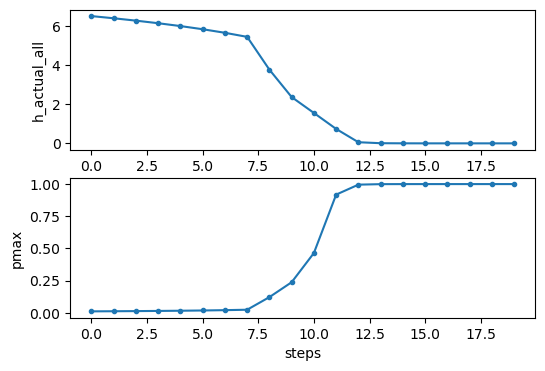

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(6,4))
ds["h_actual_all"].plot(marker=".", ax=ax[0])
(ds["d_all"].max(dim="canvas")).plot(marker=".", ax=ax[1])
ax[1].set_ylabel("pmax")
plt.show()

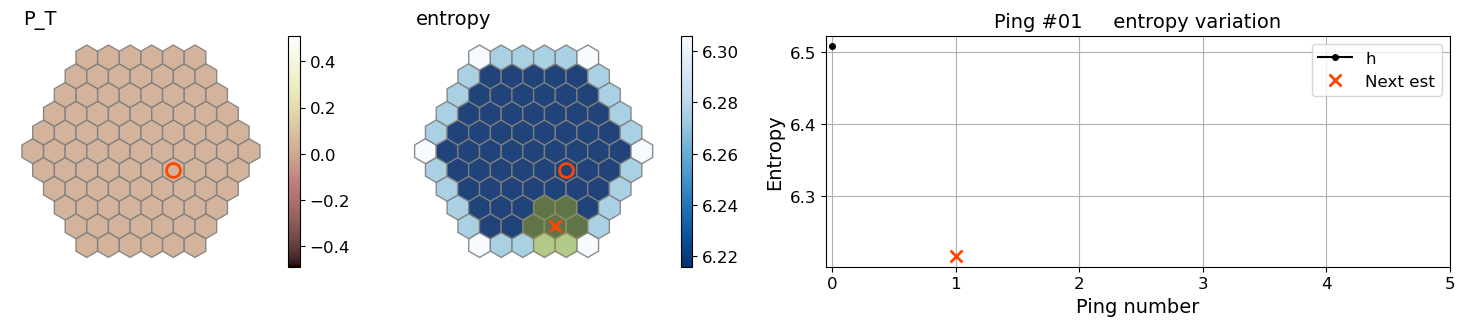

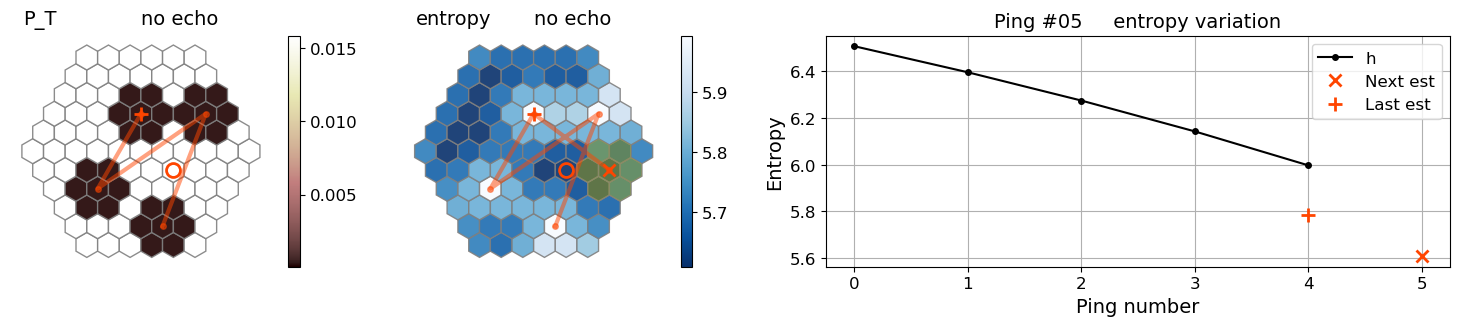

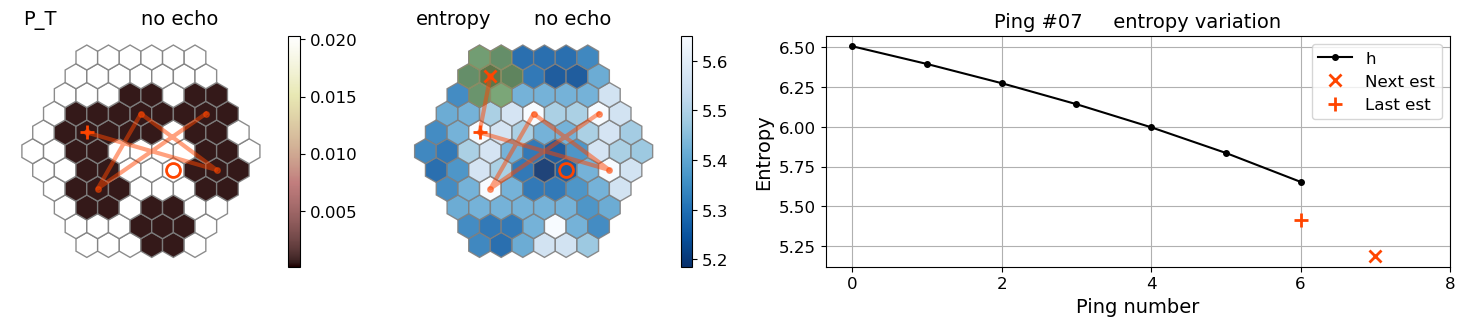

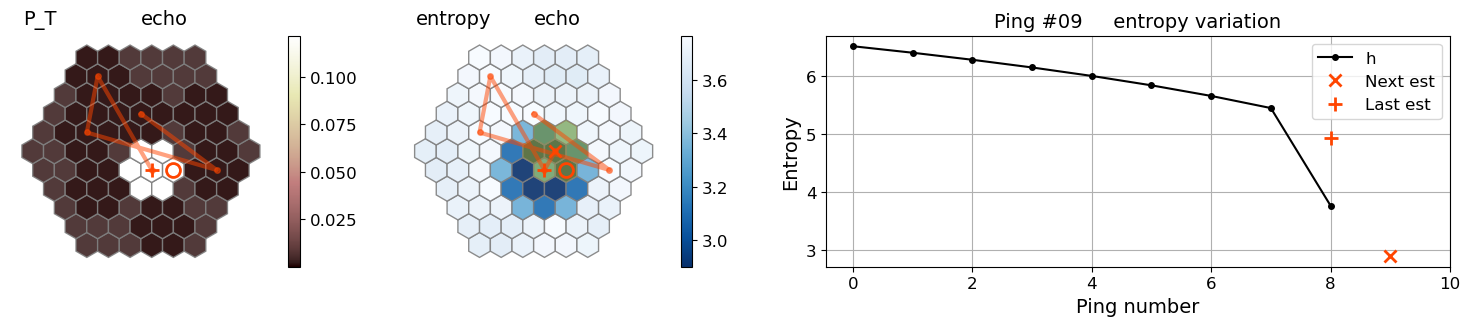

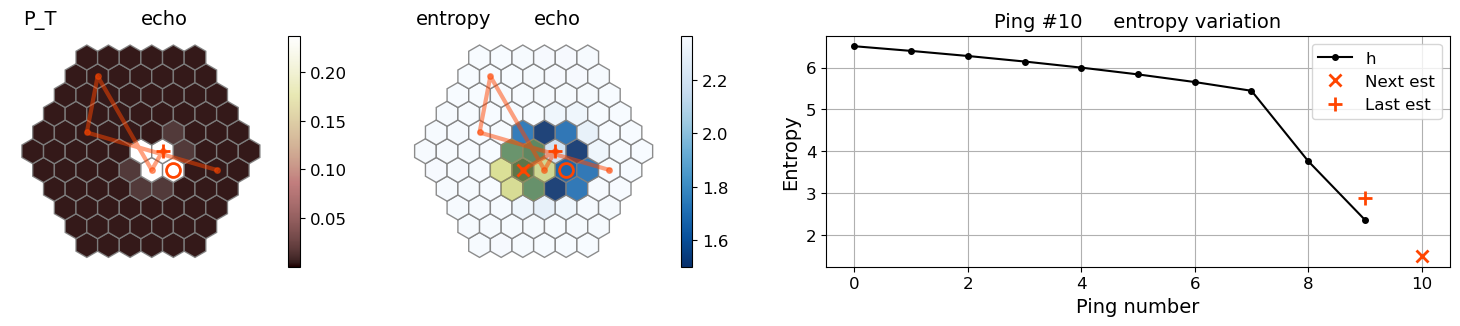

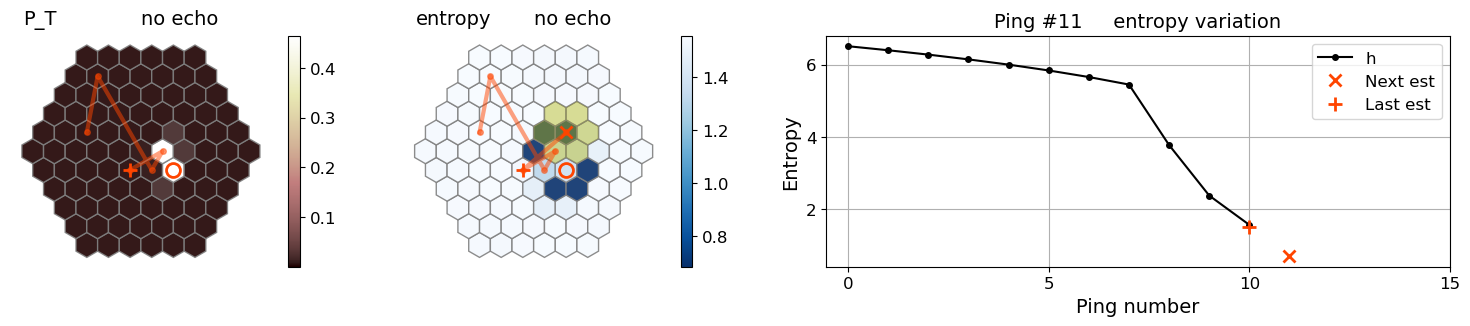

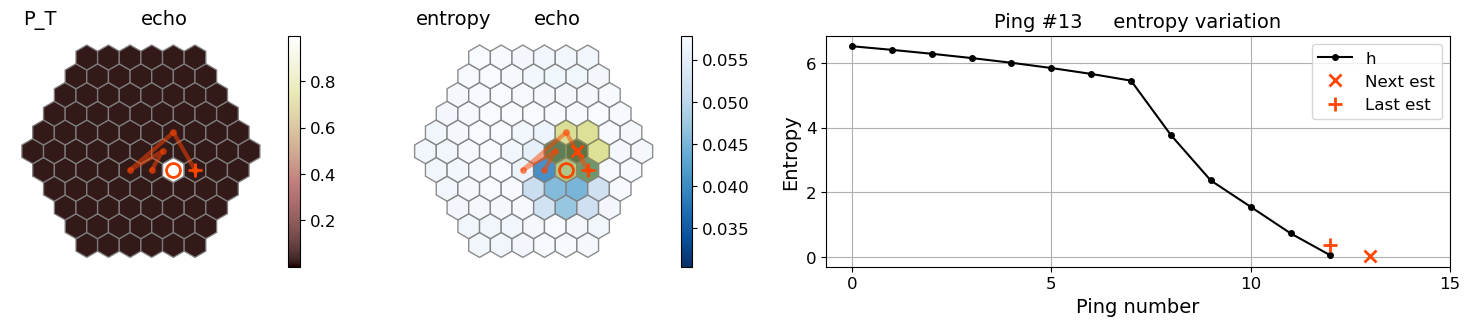

In [9]:
pings_to_plot = np.array([1, 5, 7, 9 ,10, 11, 13])
idx_to_plot = pings_to_plot-1
for idx in idx_to_plot:
    utils_plot_hex.plot_step_from_nc(ds, idx)

In [10]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_loc_standalone(ax, axis_ij, sym='o', color='m', size=10):
    ax.plot(axis_ij[0], axis_ij[1],
            markersize=size,
            marker=sym,
            markerfacecolor="None",
            markeredgecolor=color,
            markeredgewidth=1.5)

In [11]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_dk_map_standalone(ax, canvas_cube, canvas_vmap,
    beam_cube, env_attrs, plot_attrs, cmap="Blues_r",
    remove_cbar=False
):
    im, cbar = hex_ops.plot_hexgrids(ax,
                                     cube_array=canvas_cube,
                                     cube_color=canvas_vmap,
                                     cmap=cmap)
    ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    ax.axis('equal')

    # Beam and beam trace
    beam_plotxy = np.array([hex_ops.get_cube_plot_xy(x).squeeze()
                            for x in beam_cube])
    beam_trace = beam_plotxy[-6:, :]    # plot last 5 beam axis loc and the next
    beam_next = beam_plotxy[-1, :]   # next beam axis loc

    ax.plot(beam_trace[:, 0], beam_trace[:, 1], marker='.',
            color=plot_attrs['symbol_color'], alpha=0.5, linewidth=2, markersize=4)
    if beam_plotxy.shape[0] > 1:  # if there was a last beam
        plot_loc_standalone(ax=ax, axis_ij=beam_plotxy[-2, :],  # plot last beam axis
                 sym='+', color=plot_attrs['symbol_color'], size=8)
    if beam_next is not None:
        plot_loc_standalone(ax=ax, axis_ij=beam_next,  # plot last beam axis
                 sym='x', color=plot_attrs['symbol_color'], size=6)

    # Target and peg locs
    if 'target_loc' in env_attrs:
        plot_loc_standalone(ax, hex_ops.get_cube_plot_xy(env_attrs['target_loc']),
                 sym='o', color=plot_attrs['symbol_color'], size=8)  # target location

    # cbar.ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    if remove_cbar:
        cbar.remove()
    else:
        cbar.ax.set_yticks([])

In [12]:
plot_attrs = utils_plot_hex.PLOT_ATTRS
plot_attrs

{'ticklabel_fontsize': 12,
 'title_fontsize': 14,
 'axislabel_fontsize': 14,
 'legend_fontsize': 12,
 'symbol_color': 'orangered'}

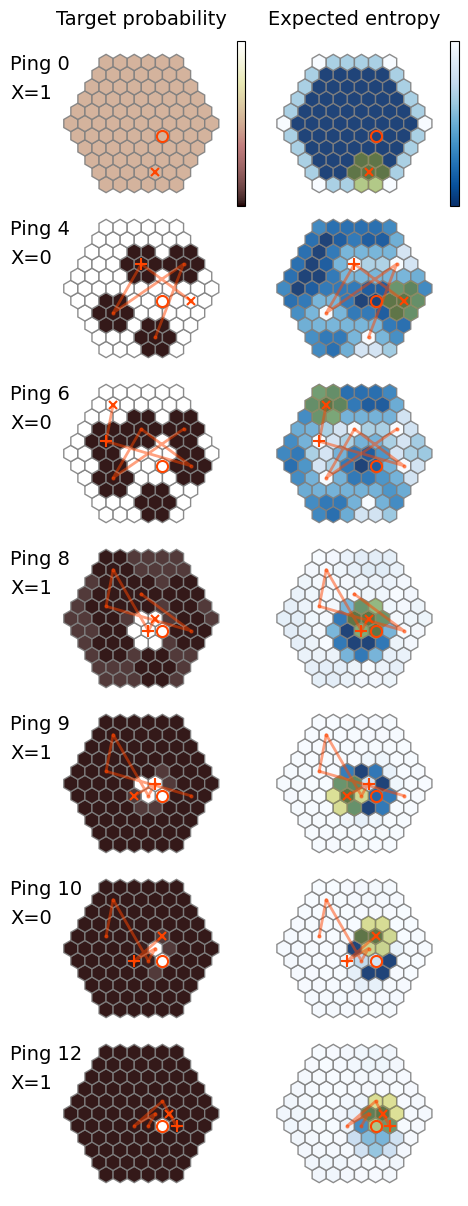

In [13]:
# Construct env_attrs for plotting
env_attrs = dict(target_loc=ds.attrs['target_loc'])

fig, ax_all = plt.subplots(7, 2, figsize=(5.5, 15))
fig.subplots_adjust(hspace=0, wspace=0)

for seq, ping_num in enumerate(idx_to_plot):

    # Whether remove colorbar
    remove_cbar = True if seq > 0 else False

    # Get beam radius
    beam_r = ds["radius_all"].isel(steps=ping_num).values

    # Target probability map
    ax = ax_all[seq, 0]
    plot_dk_map_standalone(
        ax,
        canvas_cube=ds['canvas_cube'].values,
        canvas_vmap=ds['d_all'].isel(steps=ping_num).values,
        beam_cube=ds['beam_cube_all'].isel(steps=slice(0, ping_num + 1)).values,
        env_attrs=env_attrs,
        plot_attrs=plot_attrs,
        cmap="pink",
        remove_cbar=remove_cbar
    )
    ttype = ax.text(x=-0.27, y=0.83, s=f'Ping {ping_num}',
                transform=ax.transAxes,
                fontsize=14)
    x = 0 if ds["echo_value_all"].isel(steps=ping_num).values == 0 else 1
    ttype = ax.text(x=-0.27, y=0.65, s=f'X={x}',
                transform=ax.transAxes,
                fontsize=14)
    ax.patch.set_visible(False)
    ax.axis('off')

    # Expected entropy map
    ax = ax_all[seq, 1]
    plot_dk_map_standalone(
        ax,
        canvas_cube=ds['canvas_cube'].values,
        canvas_vmap=ds['h_est_all'].isel(steps=ping_num).sel(beam_radius=beam_r).values,
        beam_cube=ds['beam_cube_all'].isel(steps=slice(0, ping_num + 1)).values,
        env_attrs=env_attrs,
        plot_attrs=plot_attrs,
        cmap="Blues_r",
        remove_cbar=remove_cbar
    )

    # Next beam coverage
    canvas_axial = hex_ops.cube_to_axial(ds['canvas_cube'])  # the entire canvas in axial coordinate
    last_beam_cover_cube = utils_plot_hex.beam_shape_hex(cube_ctr=ds['beam_cube_all'].isel(steps=ping_num).values,
                                            canvas_axial=canvas_axial,
                                            beam_radius=beam_r)
    hex_ops.plot_hexgrids(ax, cube_array=last_beam_cover_cube,
                            cube_color='y', gridalpha=0.4)

    ax.patch.set_visible(False)
    ax.axis('off')

# Add title
ax_all[0, 0].set_title("Target probability", fontsize=14, pad=12)
ax_all[0, 1].set_title("Expected entropy", fontsize=14, pad=12)

plt.show()


fig.savefig(path_fig / "fig_3A_infotaxis_simple_A.png", dpi=300, bbox_inches="tight")

In [14]:
p_max = ds["d_all"].max(dim="canvas").values
p_max

array([0.01098901, 0.01189978, 0.01297516, 0.01426421, 0.01583764,
       0.01780123, 0.02032064, 0.02367075, 0.12163686, 0.23734277,
       0.46442228, 0.91818933, 0.99558229, 0.99949289, 0.99989609,
       0.99998415, 0.99999646, 0.99999946, 0.99999988, 0.99999998])

In [15]:
pmax_diff_threshold=1e-5
criteria = {
    "pmax_repeat_N": 3,
    "max_ping_num": 500,
    "pmax_diff_threshold": pmax_diff_threshold,
}    
for p in range(len(p_max)):
    if p - criteria["pmax_repeat_N"] < 0:
        continue
    p_max_diff = np.diff(p_max[p-criteria["pmax_repeat_N"]+1:p+1])
    print(p_max_diff)
    if len(p_max_diff) > 1 and np.all(abs(p_max_diff) < criteria["pmax_diff_threshold"]):
        p_converged = p
        break

[0.00107538 0.00128905]
[0.00128905 0.00157343]
[0.00157343 0.00196359]
[0.00196359 0.0025194 ]
[0.0025194  0.00335011]
[0.00335011 0.09796611]
[0.09796611 0.11570591]
[0.11570591 0.22707951]
[0.22707951 0.45376705]
[0.45376705 0.07739296]
[0.07739296 0.0039106 ]
[0.0039106 0.0004032]
[4.03196438e-04 8.80574384e-05]
[8.80574384e-05 1.23169940e-05]
[1.23169940e-05 2.99519779e-06]
[2.99519779e-06 4.18123991e-07]


In [16]:
p_converged

18

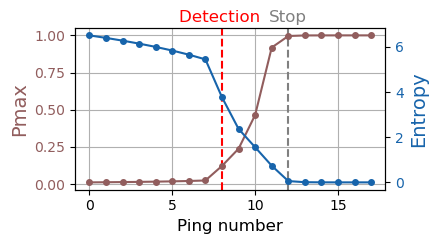

In [17]:
# Get data to plot
idx_detect = 8
h_actual_all = ds['h_actual_all'].values
p_max_all = ds['d_all'].max(dim="canvas").values

# Set up colors
cmap_tmp = matplotlib.colormaps["pink"]
colors_tmp = [cmap_tmp(c / 5) for c in range(5)]
colors = [colors_tmp[1]]
cmap_tmp = matplotlib.colormaps["Blues_r"]
colors_tmp = [cmap_tmp(c / 5) for c in range(5)]
colors.append(colors_tmp[1])


# First y-axis for pmax
fig, ax = plt.subplots(1, 1, figsize=(4, 2.1))
pingnum = len(h_actual_all[:p_converged])   # current ping number
ax.axvline(idx_detect, color="r", ls="--") # detect
ax.axvline(ping_cross, color="gray", ls="--")
ax.plot(np.arange(pingnum), p_max_all[:p_converged],  # pmax
        color=colors[0], marker='.', markersize=8, label='Pmax')

ax.set_xticks(np.arange(0, pingnum + 5, 5))
ax.set_xlabel('Ping number', fontsize=12)
ax.set_ylabel('Pmax', fontsize=14, color=colors[0])
ax.tick_params(axis='y', labelcolor=colors[0], labelsize=10)
ax.grid()

# Second y-axis for Pmax
ax2 = ax.twinx()
ax2.plot(np.arange(pingnum), h_actual_all[:p_converged],  # actual entropy
        color=colors[1], marker='.', markersize=8, label='Entropy')
ax2.set_ylabel('Entropy', fontsize=14, color=colors[1])
ax2.tick_params(axis='y', labelcolor=colors[1], labelsize=10)

ax.set_xticks(np.arange(0, 20, 5))
ax.set_xticklabels(np.arange(0, 20, 5))

# ax.set_title('Entropy and max target probability variation', fontsize=12)

ax2.text(x=ping_cross, y=7.1, s='Stop', color='gray', fontsize=12, ha="center")
ax2.text(x=idx_detect, y=7.1, s='Detection ', color='red', fontsize=12, ha="center")

plt.show()

fig.savefig(path_fig / "fig_3F_infotaxis_simple_B.png", dpi=300, bbox_inches="tight")